In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler

In [50]:
tennis = pd.read_csv('full_data.csv')
tennis["speed_kmh"] = tennis["value"].str.extract(r"(\d+)").astype(float)
tennis = tennis[["speed_kmh", "weight_kg", "height_cm", "age"]].dropna()

mean_speed = tennis["speed_kmh"].mean()
std_speed  = tennis["speed_kmh"].std()

In [51]:
scaler = StandardScaler()
tennis[['weight_kg', 'height_cm', 'age']] = scaler.fit_transform(tennis[['weight_kg', 'height_cm', 'age']])

X_weight = tennis["weight_kg"].to_numpy(dtype="float64")
X_height = tennis["height_cm"].to_numpy(dtype="float64")
X_age    = tennis["age"].to_numpy(dtype="float64")

In [ ]:
# Bayesian Linear Regression Model
with pm.Model() as model:

    w0       = pm.Normal("w0",       mu=mean_speed, sigma=std_speed)  # intercept ~ average serve speed
    w_weight = pm.Normal("w_weight", mu=0,   sigma=5)
    w_height = pm.Normal("w_height", mu=0,   sigma=5)
    w_age    = pm.Normal("w_age",    mu=0,   sigma=5)
    sigma    = pm.HalfNormal("sigma", sigma=10)

    mu = (
        w0 +
        w_weight * X_weight +
        w_height * X_height +
        w_age * X_age
    )

    speed_obs = pm.Normal("speed_obs", mu=mu, sigma=sigma, observed=tennis["speed_kmh"])

    trace = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.9, return_inferencedata=True)

            mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
w0        177.86  0.68  176.64   179.23       0.01     0.01  10246.49   
w_weight    2.05  1.06    0.07     4.09       0.01     0.01   5406.21   
w_height    4.26  1.06    2.29     6.26       0.01     0.01   5249.43   
w_age      -1.15  0.70   -2.51     0.11       0.01     0.01   7498.68   
sigma       6.79  0.49    5.89     7.73       0.01     0.01   8412.00   

          ess_tail  r_hat  
w0         5277.37    1.0  
w_weight   5609.06    1.0  
w_height   5090.27    1.0  
w_age      5646.82    1.0  
sigma      6253.58    1.0  


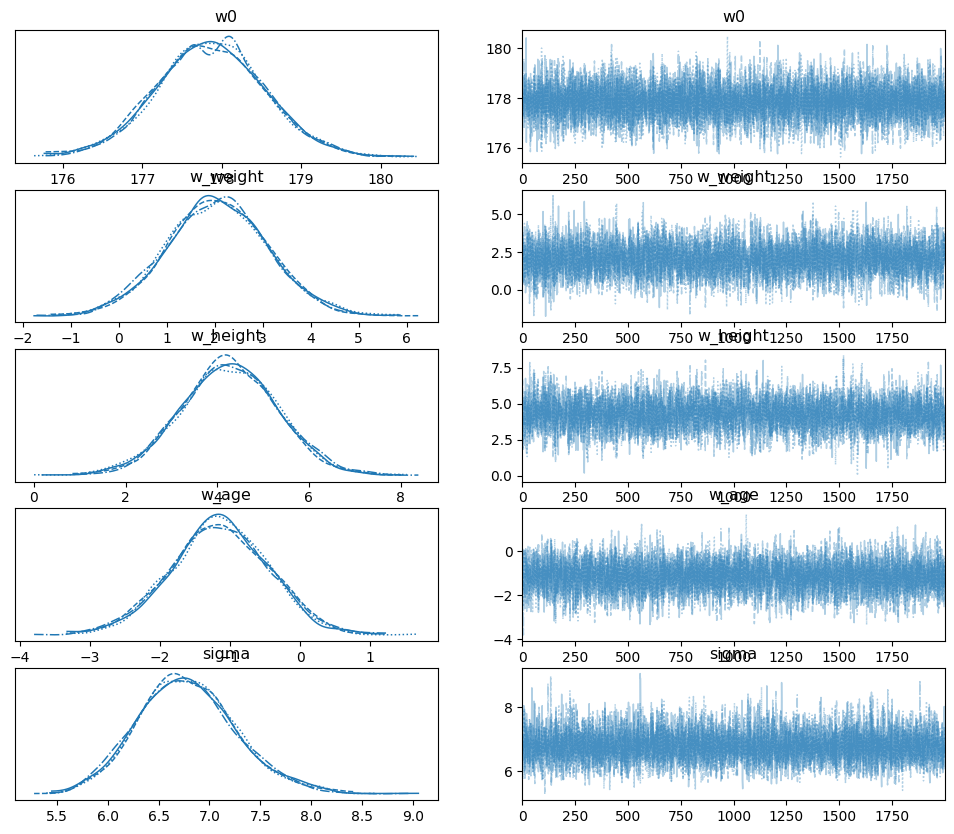

In [53]:
print(az.summary(trace, var_names=["w0", "w_weight", "w_height", "w_age", "sigma"], round_to=2))
az.plot_trace(trace, var_names=["w0", "w_weight", "w_height", "w_age", "sigma"])
plt.show()

Making Predictions

In [54]:
post = az.extract(trace, var_names=["w0", "w_weight", "w_height", "w_age", "sigma"])

new = scaler.transform(pd.DataFrame([[85.0, 193.0, 27.0]], columns=['weight_kg', 'height_cm', 'age']))  # 85kg, 193cm, 27yo

mu_new = post["w0"].values + post["w_weight"].values * new[0,0] + \
         post["w_height"].values * new[0,1] + post["w_age"].values * new[0,2]
preds = np.random.normal(mu_new, post["sigma"].values)
print(f"Predicted: {preds.mean():.1f} km/h")

Predicted: 184.1 km/h


In [55]:
same_but_older = scaler.transform(pd.DataFrame([[85.0, 193.0, 35.0]], columns=['weight_kg', 'height_cm', 'age']))  # 85kg, 193cm, 35yo

mu_new = post["w0"].values + post["w_weight"].values * same_but_older[0,0] + \
         post["w_height"].values * same_but_older[0,1] + post["w_age"].values * same_but_older[0,2]

preds = np.random.normal(mu_new, post["sigma"].values)
print(f"Predicted: {preds.mean():.1f} km/h")

Predicted: 181.9 km/h


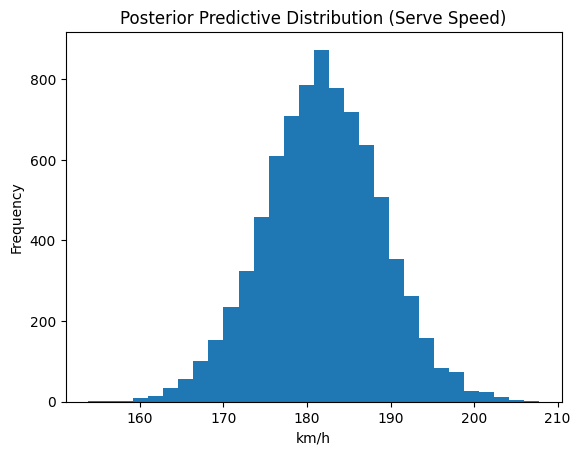

In [56]:
plt.hist(preds, bins=30)
plt.title("Posterior Predictive Distribution (Serve Speed)")
plt.xlabel("km/h")
plt.ylabel("Frequency")
plt.show()